In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
rng = np.random.default_rng(42)

base = "https://raw.githubusercontent.com/jorisroelofs95/EfDS_assignments/main/assignment_C/out/"

bmi = pd.read_csv(base + "merged_dataset.csv")


## the goal is to 
## 1) analyse the distribution of bmi in different populations
## 2) determine if BMI is related to the expression of certain genes

In [4]:
print(bmi)

           id  weight  height     sex smokes country    bmi source      geneA  \
0     NL_0001     105     188    male    yes      NL  29.71     NL   2.852573   
1     NL_0002     114     177    male    yes      NL  36.39     NL  23.406720   
2     NL_0003      70     176  female     no      NL  22.60     NL   0.375769   
3     NL_0004      68     175    male     no      NL  22.20     NL   0.800761   
4     NL_0005      86     186    male    yes      NL  24.86     NL   1.008053   
...       ...     ...     ...     ...    ...     ...    ...    ...        ...   
3367    S1149      95     190    male     no      US  26.32     US   0.471653   
3368    S1204      90     179    male     no      US  28.09     US   0.741639   
3369    S1075      74     170    male    yes      US  25.61     US   0.490165   
3370    S1171      97     173    male     no      US  32.41     US   2.144371   
3371    S1207      70     169    male     no      US  24.51     US   0.340582   

          geneB       geneC

Firstly, I'll create a plot showing distribution of BMI categories


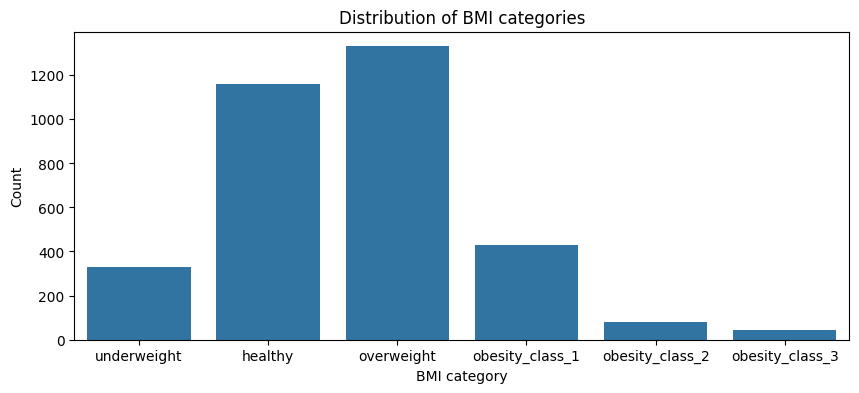

The percentage of healthy people across 4 countries is 34%. The percentage of people with overweight across 4 countries is 55%. 
This is bad news and will cost society much. An idea: we need to sit less, so next class everybody should stand half of the time!


In [5]:
print(f"Firstly, I'll create a plot showing distribution of BMI categories")

plt.figure(figsize=(10,4))

category_order = ["underweight", "healthy", "overweight", "obesity_class_1", "obesity_class_2", "obesity_class_3"]

sns.countplot(data=bmi, x="bmi_category", order=category_order)

plt.title("Distribution of BMI categories")
plt.xlabel("BMI category")
plt.ylabel("Count")

plt.show()

healthy_percentage = int(( (bmi["bmi_category"] == "healthy").sum() / len(bmi) ) * 100)
overweight_percentage = int((bmi["bmi_category"].isin(["overweight", "obesity_class_1", "obesity_class_2", "obesity_class_3"]).sum() / len(bmi)) * 100)
print(f"The percentage of healthy people across 4 countries is {healthy_percentage}%. The percentage of people with overweight across 4 countries is {overweight_percentage}%. ")
print(f"This is bad news and will cost society much. An idea: we need to sit less, so next class everybody should stand half of the time!")

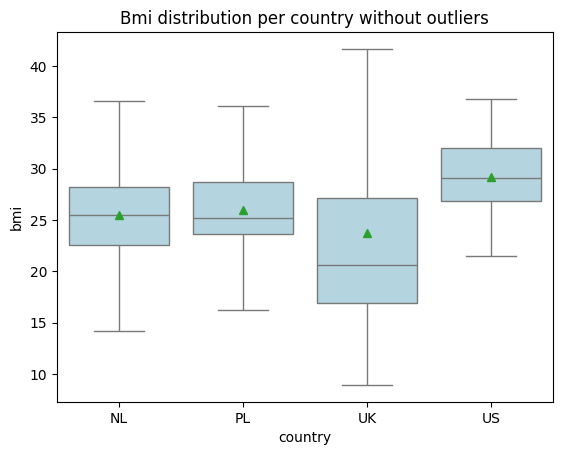

It seems that the US have the highest bmi on average and as most common, than the PL and than NL
the UK is hard to interpret given there lowest 25% have quite more underweight than the other countries. While the higest 25% have a really high bmi compared to other countries


In [6]:
sns.boxplot(data=bmi, x="country", y="bmi", showfliers=False, showmeans=True, color="lightblue")
plt.title("Bmi distribution per country without outliers")
plt.show()

print(f"It seems that the US have the highest bmi on average and as most common, than the PL and than NL")
print(f"the UK is hard to interpret given there lowest 25% have quite more underweight than the other countries. While the higest 25% have a really high bmi compared to other countries")

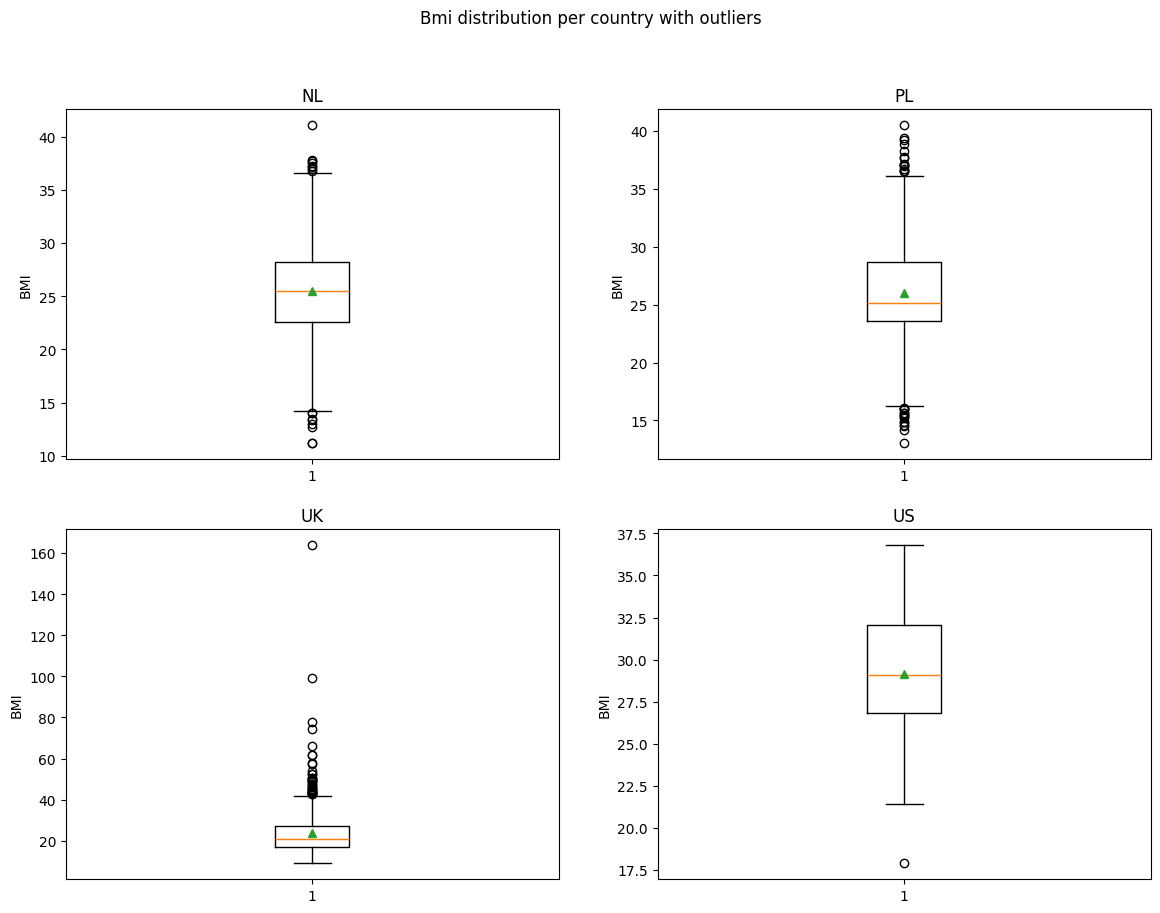

Here we see that the UK has a lot of outliers (very unhealthy people). The data of the US show little outliers.
I would've expect the US to have people with a very high BMI, but thats in this data not the case


In [7]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(14,10))
fig.suptitle('Bmi distribution per country with outliers')

ax1.boxplot(bmi[bmi["country"] == "NL"]["bmi"], showmeans=True)
ax1.set_title("NL")
ax1.set_ylabel("BMI")

ax2.boxplot(bmi[bmi["country"] == "PL"]["bmi"], showmeans=True)
ax2.set_title("PL")
ax2.set_ylabel("BMI")

ax3.boxplot(bmi[bmi["country"] == "UK"]["bmi"], showmeans=True)
ax3.set_title("UK")
ax3.set_ylabel("BMI")

ax4.boxplot(bmi[bmi["country"] == "US"]["bmi"], showmeans=True)
ax4.set_title("US")
ax4.set_ylabel("BMI")

plt.show()

print(f"Here we see that the UK has a lot of outliers (very unhealthy people). The data of the US show little outliers.\n"
f"I would've expect the US to have people with a very high BMI, but thats in this data not the case")

Sample size per country
PL    1397
NL    1322
UK     586
US      67
Name: count, dtype: int64


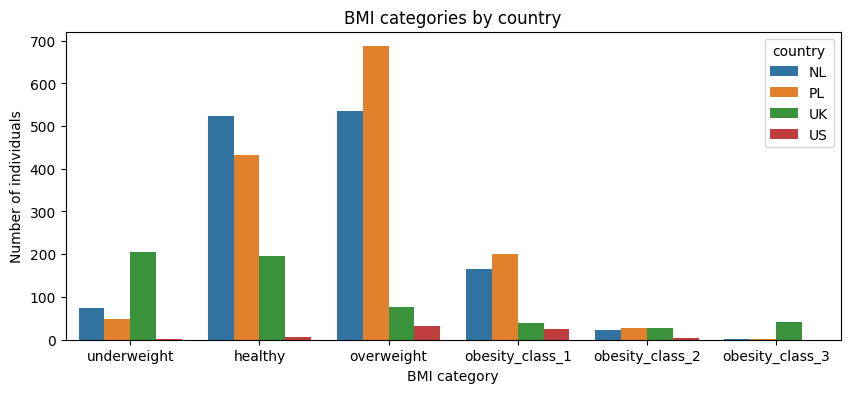

Sample size is low in the UK, they have by far the most obesitas 2 and 3 people. This would make them a candidate for the most unhealthy country


In [8]:
print(f"Sample size per {bmi["country"].value_counts()}")

plt.figure(figsize=(10,4))

category_order = ["underweight", "healthy", "overweight", "obesity_class_1", "obesity_class_2", "obesity_class_3"]

sns.countplot(data=bmi, x="bmi_category", hue="country", order=category_order)

plt.xlabel("BMI category")
plt.ylabel("Number of individuals")
plt.title("BMI categories by country")

plt.show()

print(f"Sample size is low in the UK, they have by far the most obesitas 2 and 3 people. This would make them a candidate for the most unhealthy country")

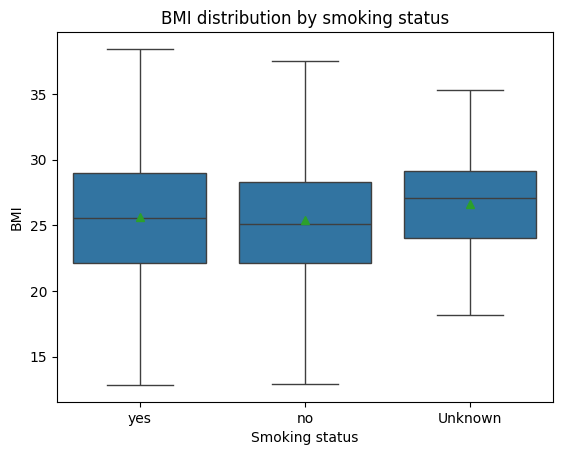

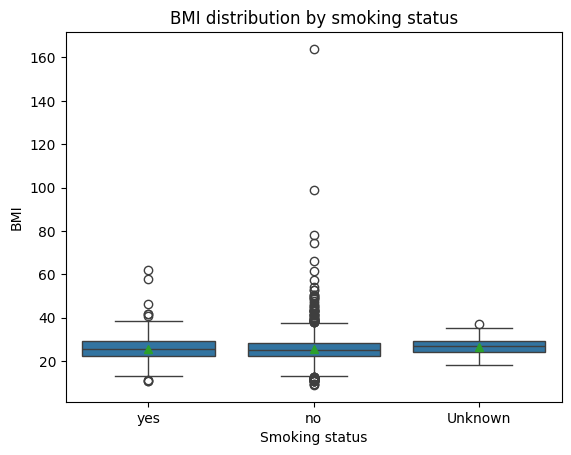

Based on these boxplots, I would say that if you are a smoker, its more likely you have an extreme high or low bmi that is unhealthy
However, on average, there is not much difference and 50% of the people in the sample are likely to have roughly the same bmi around 25


In [9]:
sns.boxplot(data=bmi, x="smokes", y="bmi", showmeans=True, showfliers=False)

plt.xlabel("Smoking status")
plt.ylabel("BMI")
plt.title("BMI distribution by smoking status")

plt.show()

sns.boxplot(data=bmi, x="smokes", y="bmi", showmeans=True)

plt.xlabel("Smoking status")
plt.ylabel("BMI")
plt.title("BMI distribution by smoking status")

plt.show()

print(f"Based on these boxplots, I would say that if you are a smoker, its more likely you have an extreme high or low bmi that is unhealthy")
print(f"However, on average, there is not much difference and 50% of the people in the sample are likely to have roughly the same bmi around 25")

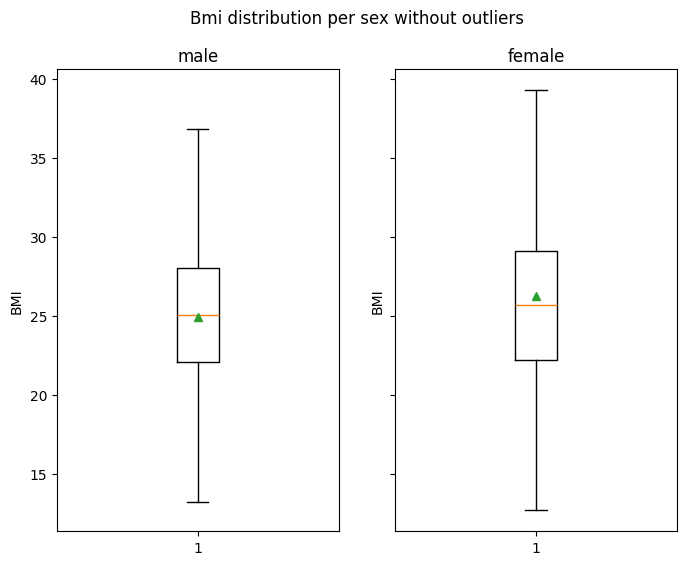

The boxplots, the means and medians suggests males to have a slightly healthier bmi than females in the sample.


In [10]:
fig, ((ax1,ax2)) = plt.subplots(1,2, figsize=(8,6), sharey=True) # try argument sharex, sharey, figsize. 2 is the nr of ros and 2 of columns
fig.suptitle('Bmi distribution per sex without outliers')

ax1.boxplot(bmi[bmi["sex"] == "male"]["bmi"], showmeans=True, showfliers=False)
ax1.set_title("male")
ax1.set_ylabel("BMI")

ax2.boxplot(bmi[bmi["sex"] == "female"]["bmi"], showmeans=True, showfliers=False)
ax2.set_title("female")
ax2.set_ylabel("BMI")

plt.show()

print(f"The boxplots, the means and medians suggests males to have a slightly healthier bmi than females in the sample.")

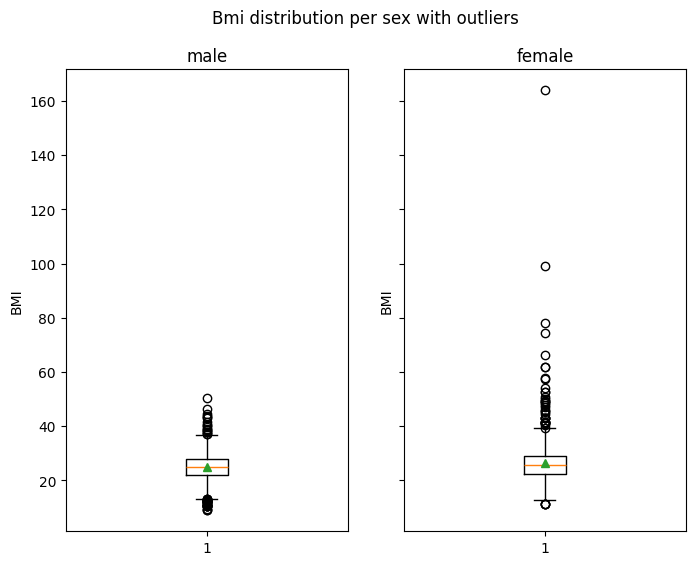

The boxplots with outliers suggests females to have more extreme obesitas than males.


In [11]:
fig, ((ax1,ax2)) = plt.subplots(1,2, figsize=(8,6), sharey=True) # try argument sharex, sharey, figsize. 2 is the nr of ros and 2 of columns
fig.suptitle('Bmi distribution per sex with outliers')

ax1.boxplot(bmi[bmi["sex"] == "male"]["bmi"], showmeans=True)
ax1.set_title("male")
ax1.set_ylabel("BMI")

ax2.boxplot(bmi[bmi["sex"] == "female"]["bmi"], showmeans=True)
ax2.set_title("female")
ax2.set_ylabel("BMI")

plt.show()

print(f"The boxplots with outliers suggests females to have more extreme obesitas than males.")

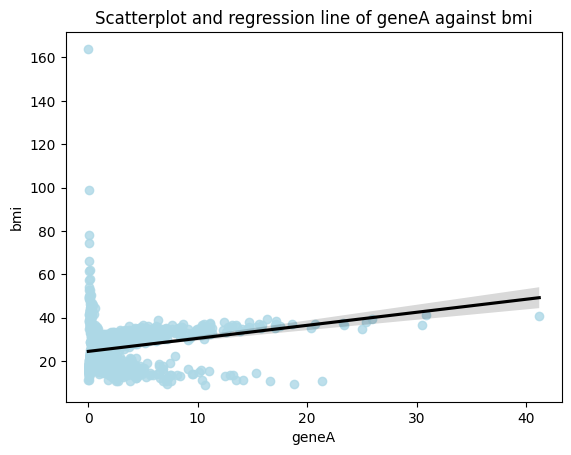

There is a correlation here, if you look at the line. The higher the value of geneA, the higher bmi will likely to be.


In [12]:
sns.regplot(data=bmi, x="geneA", y="bmi", scatter_kws={"color": "lightblue"}, line_kws={"color": "black"})
plt.title("Scatterplot and regression line of geneA against bmi")

plt.show()

print(f"There is a correlation here, if you look at the line. The higher the value of geneA, the higher bmi will likely to be.")

Sample size per bmi_category
overweight         1331
healthy            1158
obesity_class_1     430
underweight         329
obesity_class_2      80
obesity_class_3      44
Name: count, dtype: int64


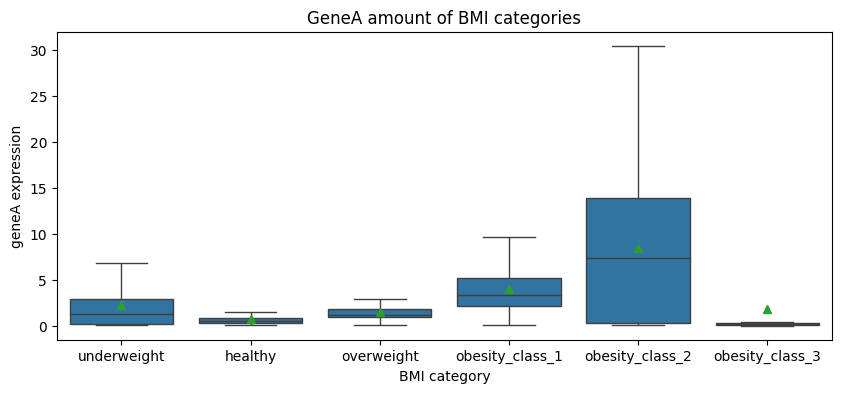

In [13]:
print(f"Sample size per {bmi["bmi_category"].value_counts()}")

plt.figure(figsize=(10,4))

category_order = ["underweight", "healthy", "overweight", "obesity_class_1", "obesity_class_2", "obesity_class_3"]

sns.boxplot(data=bmi, x="bmi_category", y="geneA", showfliers=False, order=category_order, showmeans=True)

plt.title("GeneA amount of BMI categories")
plt.xlabel("BMI category")
plt.ylabel("geneA expression")

plt.show()

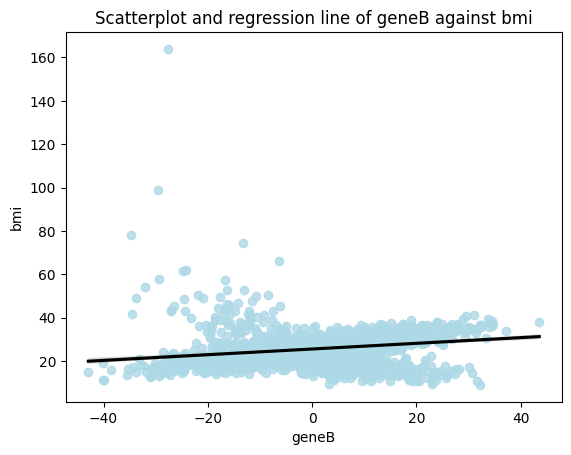

There is some correlation here, if you look at the line. The higher geneB, the higher bmi will likely to be. However, the line is less steep than with geneA


In [14]:
sns.regplot(data=bmi, x="geneB", y="bmi", scatter_kws={"color": "lightblue"}, line_kws={"color": "black"})
plt.title("Scatterplot and regression line of geneB against bmi")
plt.show()
print(f"There is some correlation here, if you look at the line. The higher geneB, the higher bmi will likely to be. However, the line is less steep than with geneA")

Sample size per bmi_category
overweight         1331
healthy            1158
obesity_class_1     430
underweight         329
obesity_class_2      80
obesity_class_3      44
Name: count, dtype: int64


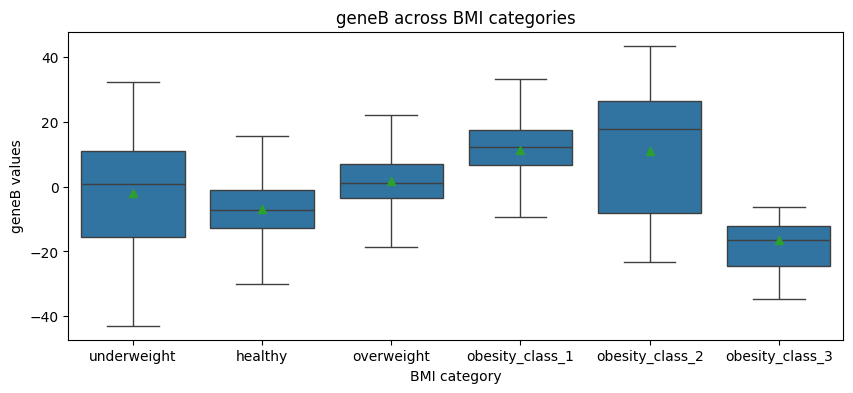

This makes our previous assumption stronger. The higher geneB, the more unhealthy people will be. Although obesity_class_3 is different, but sample size is low here


In [15]:
print(f"Sample size per {bmi["bmi_category"].value_counts()}")

plt.figure(figsize=(10,4))

category_order = ["underweight", "healthy", "overweight", "obesity_class_1", "obesity_class_2", "obesity_class_3"]

sns.boxplot(data=bmi, x="bmi_category", y="geneB", showfliers=False, order=category_order, showmeans=True)

plt.title("geneB across BMI categories")
plt.xlabel("BMI category")
plt.ylabel("geneB values")

plt.show()
print(f"This makes our previous assumption stronger. The higher geneB, the more unhealthy people will be. Although obesity_class_3 is different, but sample size is low here")

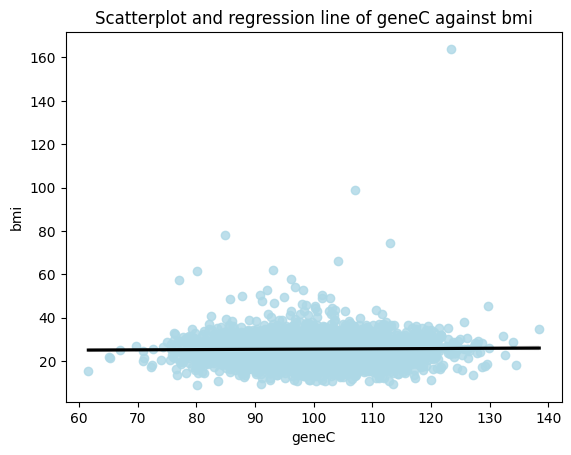

There doesnt seem to be any correlation here. GeneC has no influence on bmi. The line is level


In [16]:
sns.regplot(data=bmi, x="geneC", y="bmi", scatter_kws={"color": "lightblue"}, line_kws={"color": "black"})
plt.title("Scatterplot and regression line of geneC against bmi")
plt.show()

print(f"There doesnt seem to be any correlation here. GeneC has no influence on bmi. The line is level")

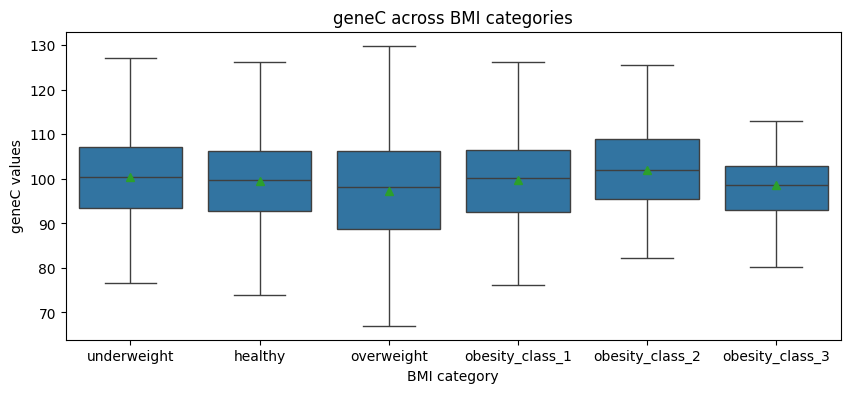

There doesn't seem to be any correlation here


In [17]:
plt.figure(figsize=(10,4))

category_order = ["underweight", "healthy", "overweight", "obesity_class_1", "obesity_class_2", "obesity_class_3"]

sns.boxplot(data=bmi, x="bmi_category", y="geneC", showfliers=False, order=category_order, showmeans=True)

plt.title("geneC across BMI categories")
plt.xlabel("BMI category")
plt.ylabel("geneC values")

plt.show()
print(f"There doesn't seem to be any correlation here")

# Conclusions based on the sample:
# -55% of all the people have an unhealthy bmi.
# -NL relatively have the most people with a healthy bmi.
# -The US does not have so much obesitas people, as we would expect.
# -The most extreme forms of an unhealthy bmi (underweight and obesitas classes) prevaily most often in the UK.
# -There is not much difference between smokers and nonsmokers in bmi. Although smokers relatively have more obesitas, but on average have a lower bmi.
# -There is not much difference between males and females, but females have slightly higher bmi.
# -Females have more extreme forms of unhealthy bmi (underweight and obesitas)
# -A higher geneA value correlates to a higher bmi.
# -A higher geneB value correlates to a higher bmi, but the correlations is less strong as with geneA
# -GeneC has no correlation with bmi.

# 